# Ensemble Model

This notebook combines predictions from all individual models (LSTM, Random Forest, XGBoost, AdaBoost) using ensemble strategies.

## Ensemble Strategies:
1. Simple Averaging
2. Weighted Averaging (based on model performance)
3. Voting Classifier (for classification)
4. Stacking (using meta-learners)

## Available Models:
- Random Forest (RF): Regression and Classification
- XGBoost (XGB): Regression and Classification
- AdaBoost (ADA): Regression and Classification
- LSTM: Will be included if available


In [44]:
# Import required libraries
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)
from sklearn.ensemble import VotingRegressor, VotingClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import cross_val_score
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")

print("✓ Libraries imported successfully!")


✓ Libraries imported successfully!


## Step 1: Load Predictions from Available Models

Load predictions from all available models. Models that don't exist will be skipped.


In [ ]:
# Define paths and check which models are available
# Handle different working directories (notebooks/ vs project root)
import os

# Get current working directory
cwd = os.getcwd()
print(f"Current working directory: {cwd}")

# Determine base path - if we're in notebooks/, go up one level
if os.path.basename(cwd) == 'notebooks':
    base_path = '..'
else:
    base_path = '.'

# Define paths relative to base
team_paths = {
    'lstm': os.path.join(base_path, 'models', 'lstm'),
    'random_forest': os.path.join(base_path, 'models', 'random_forest'),
    'xgboost_adaboost': os.path.join(base_path, 'models', 'xgboost_adaboost')
}

available_models = {}

# Check for Random Forest
rf_val_path = os.path.join(base_path, 'models', 'random_forest', 'predictions_val.csv')
rf_test_path = os.path.join(base_path, 'models', 'random_forest', 'predictions_test.csv')
print(f"Checking Random Forest: {rf_val_path} (exists: {os.path.exists(rf_val_path)})")
if os.path.exists(rf_val_path) and os.path.exists(rf_test_path):
    available_models['random_forest'] = {
        'val_path': rf_val_path,
        'test_path': rf_test_path,
        'name': 'Random Forest'
    }
    print("✓ Random Forest predictions found")

# Check for XGBoost/AdaBoost
xgb_val_path = os.path.join(base_path, 'models', 'xgboost_adaboost', 'predictions_val.csv')
xgb_test_path = os.path.join(base_path, 'models', 'xgboost_adaboost', 'predictions_test.csv')
print(f"Checking XGBoost/AdaBoost: {xgb_val_path} (exists: {os.path.exists(xgb_val_path)})")
if os.path.exists(xgb_val_path) and os.path.exists(xgb_test_path):
    available_models['xgboost_adaboost'] = {
        'val_path': xgb_val_path,
        'test_path': xgb_test_path,
        'name': 'XGBoost/AdaBoost'
    }
    print("✓ XGBoost/AdaBoost predictions found")

# Check for LSTM
lstm_val_path = os.path.join(base_path, 'models', 'lstm', 'predictions_val.csv')
lstm_test_path = os.path.join(base_path, 'models', 'lstm', 'predictions_test.csv')
print(f"Checking LSTM: {lstm_val_path} (exists: {os.path.exists(lstm_val_path)})")

# Check if LSTM validation file exists and is valid
lstm_val_valid = False
lstm_test_valid = False

if os.path.exists(lstm_val_path):
    try:
        # Try to read and validate the file
        test_df = pd.read_csv(lstm_val_path, nrows=5)
        if len(test_df) > 0 and 'predicted_heat_index' in test_df.columns:
            lstm_val_valid = True
            print("✓ LSTM validation predictions found and valid")
        else:
            print("⚠ LSTM validation file exists but is invalid")
    except Exception as e:
        print(f"⚠ LSTM validation file exists but cannot be read: {e}")

# Check if LSTM test file exists and is valid
if os.path.exists(lstm_test_path):
    try:
        test_df = pd.read_csv(lstm_test_path, nrows=5)
        if len(test_df) > 0 and 'predicted_heat_index' in test_df.columns:
            lstm_test_valid = True
            print("✓ LSTM test predictions found and valid")
        else:
            print("⚠ LSTM test file exists but is invalid (will use validation only)")
    except Exception as e:
        print(f"⚠ LSTM test file exists but cannot be read: {e}")

# Add LSTM if at least validation is available
if lstm_val_valid:
    available_models['lstm'] = {
        'val_path': lstm_val_path,
        'test_path': lstm_test_path if lstm_test_valid else None,
        'name': 'LSTM',
        'test_available': lstm_test_valid
    }
    if not lstm_test_valid:
        print("⚠ LSTM test predictions not available - will only use validation set")
else:
    print("⚠ LSTM predictions not found or invalid - will skip LSTM in ensemble")

print(f"\n✓ Total available models: {len(available_models)}")
print(f"Available models: {', '.join([m['name'] for m in available_models.values()])}")


Current working directory: c:\Users\hrudi\OneDrive\Documents\TAMU\SHADE\ML-Repo\notebooks
Checking Random Forest: ..\teams\random_forest\predictions_val.csv (exists: True)
✓ Random Forest predictions found
Checking XGBoost/AdaBoost: ..\teams\xgboost_adaboost\predictions_val.csv (exists: True)
✓ XGBoost/AdaBoost predictions found
Checking LSTM: ..\teams\lstm\predictions_val.csv (exists: True)
✓ LSTM validation predictions found and valid
✓ LSTM test predictions found and valid

✓ Total available models: 3
Available models: Random Forest, XGBoost/AdaBoost, LSTM


In [53]:
# Load predictions from available models
predictions_val = {}
predictions_test = {}

# Load Random Forest predictions
if 'random_forest' in available_models:
    rf_val = pd.read_csv(available_models['random_forest']['val_path'])
    rf_test = pd.read_csv(available_models['random_forest']['test_path'])
    
    # Standardize column names
    rf_val = rf_val.rename(columns={
        'predicted_heat_index': 'rf_predicted_heat_index',
        'predicted_heat_risk': 'rf_predicted_heat_risk',
        'predicted_heat_risk_proba': 'rf_predicted_heat_risk_proba'
    })
    rf_test = rf_test.rename(columns={
        'predicted_heat_index': 'rf_predicted_heat_index',
        'predicted_heat_risk': 'rf_predicted_heat_risk',
        'predicted_heat_risk_proba': 'rf_predicted_heat_risk_proba'
    })
    
    predictions_val['random_forest'] = rf_val
    predictions_test['random_forest'] = rf_test
    print(f"✓ Loaded Random Forest: {len(rf_val)} validation, {len(rf_test)} test samples")

# Load XGBoost/AdaBoost predictions
if 'xgboost_adaboost' in available_models:
    xgb_val = pd.read_csv(available_models['xgboost_adaboost']['val_path'])
    xgb_test = pd.read_csv(available_models['xgboost_adaboost']['test_path'])
    
    predictions_val['xgboost_adaboost'] = xgb_val
    predictions_test['xgboost_adaboost'] = xgb_test
    print(f"✓ Loaded XGBoost/AdaBoost: {len(xgb_val)} validation, {len(xgb_test)} test samples")

# Load LSTM predictions
if 'lstm' in available_models:
    try:
        lstm_val = pd.read_csv(available_models['lstm']['val_path'])
        
        # Handle "Ellipsis" values - replace with NaN
        # Convert columns that might contain "Ellipsis" strings
        # IMPORTANT: Exclude Date column from numeric conversion
        for col in lstm_val.columns:
            if lstm_val[col].dtype == 'object' and col != 'Date':
                # Replace "Ellipsis" string with NaN
                lstm_val[col] = lstm_val[col].replace('Ellipsis', np.nan)
                # Try to convert to numeric if possible
                try:
                    lstm_val[col] = pd.to_numeric(lstm_val[col], errors='coerce')
                except:
                    pass
        
        # Standardize column names
        lstm_val = lstm_val.rename(columns={
            'predicted_heat_index': 'lstm_predicted_heat_index',
            'predicted_heat_risk': 'lstm_predicted_heat_risk',
            'predicted_heat_risk_proba': 'lstm_predicted_heat_risk_proba'
        })
        
        # Ensure Date column is properly formatted
        if 'Date' in lstm_val.columns:
            lstm_val['Date'] = pd.to_datetime(lstm_val['Date'], errors='coerce')
        
        # Remove rows with invalid dates
        lstm_val = lstm_val.dropna(subset=['Date'])
        
        predictions_val['lstm'] = lstm_val
        print(f"✓ Loaded LSTM validation: {len(lstm_val)} samples")
        
        # Load test predictions if available
        if available_models['lstm'].get('test_available', False) and available_models['lstm']['test_path']:
            try:
                lstm_test = pd.read_csv(available_models['lstm']['test_path'])
                
                # Handle "Ellipsis" values
                # IMPORTANT: Exclude Date column from numeric conversion
                for col in lstm_test.columns:
                    if lstm_test[col].dtype == 'object' and col != 'Date':
                        lstm_test[col] = lstm_test[col].replace('Ellipsis', np.nan)
                        try:
                            lstm_test[col] = pd.to_numeric(lstm_test[col], errors='coerce')
                        except:
                            pass
                
                # Standardize column names
                lstm_test = lstm_test.rename(columns={
                    'predicted_heat_index': 'lstm_predicted_heat_index',
                    'predicted_heat_risk': 'lstm_predicted_heat_risk',
                    'predicted_heat_risk_proba': 'lstm_predicted_heat_risk_proba'
                })
                
                # Ensure Date column is properly formatted
                if 'Date' in lstm_test.columns:
                    lstm_test['Date'] = pd.to_datetime(lstm_test['Date'], errors='coerce')
                
                # Remove rows with invalid dates
                lstm_test = lstm_test.dropna(subset=['Date'])
                
                predictions_test['lstm'] = lstm_test
                print(f"✓ Loaded LSTM test: {len(lstm_test)} samples")
            except Exception as e:
                print(f"⚠ Could not load LSTM test predictions: {e}")
                print("   Will proceed without LSTM test predictions")
        else:
            print("⚠ LSTM test predictions not available - will skip in test set")
            
    except Exception as e:
        print(f"⚠ Error loading LSTM predictions: {e}")
        print("   Will proceed without LSTM in ensemble")

print(f"\n✓ Successfully loaded predictions from {len(predictions_val)} model(s)")


✓ Loaded Random Forest: 1553 validation, 1552 test samples
✓ Loaded XGBoost/AdaBoost: 1355 validation, 1355 test samples
✓ Loaded LSTM validation: 1539 samples
✓ Loaded LSTM test: 1538 samples

✓ Successfully loaded predictions from 3 model(s)


## Step 2: Align Predictions by Date

Merge all predictions on the Date column to ensure alignment.


In [54]:
# Merge all validation predictions on Date
# First, find a model with valid actual values to use as base
val_merged = None
base_actuals = None

# Find first model with valid actual values
for model_name, pred_df in predictions_val.items():
    if 'actual_heat_index' in pred_df.columns and 'actual_heat_risk' in pred_df.columns:
        # Check if actual values are valid (not all NaN/Ellipsis)
        if pred_df['actual_heat_index'].notna().sum() > 0:
            base_actuals = pred_df[['Date', 'actual_heat_index', 'actual_heat_risk']].copy()
            # Convert Date to datetime
            base_actuals['Date'] = pd.to_datetime(base_actuals['Date'], errors='coerce')
            base_actuals = base_actuals.dropna(subset=['Date'])
            val_merged = base_actuals.copy()
            print(f"✓ Using actual values from {model_name} as base")
            break

# If no model has valid actuals, use first model's structure
if val_merged is None:
    first_model = list(predictions_val.keys())[0]
    pred_df = predictions_val[first_model]
    val_merged = pred_df[['Date']].copy()
    val_merged['Date'] = pd.to_datetime(val_merged['Date'], errors='coerce')
    val_merged = val_merged.dropna(subset=['Date'])
    # Add placeholder actual columns
    val_merged['actual_heat_index'] = np.nan
    val_merged['actual_heat_risk'] = np.nan
    print(f"⚠ No valid actual values found, using {first_model} structure")

# Merge predictions from all models
for model_name, pred_df in predictions_val.items():
    # Get prediction columns (exclude Date and actual columns)
    pred_cols = [col for col in pred_df.columns 
                 if col not in ['Date', 'actual_heat_index', 'actual_heat_risk']]
    
    if len(pred_cols) > 0:
        # Prepare merge dataframe
        merge_df = pred_df[['Date'] + pred_cols].copy()
        merge_df['Date'] = pd.to_datetime(merge_df['Date'], errors='coerce')
        merge_df = merge_df.dropna(subset=['Date'])
        
        # Merge on Date
        val_merged = val_merged.merge(
            merge_df,
            on='Date',
            how='inner',
            suffixes=('', f'_{model_name}')
        )

# Fill in actual values if missing (use first non-null value from any model)
if val_merged['actual_heat_index'].isna().any():
    for model_name, pred_df in predictions_val.items():
        if 'actual_heat_index' in pred_df.columns:
            pred_df['Date'] = pd.to_datetime(pred_df['Date'], errors='coerce')
            merge_actuals = pred_df[['Date', 'actual_heat_index', 'actual_heat_risk']].copy()
            merge_actuals = merge_actuals.dropna(subset=['Date', 'actual_heat_index'])
            val_merged = val_merged.merge(
                merge_actuals[['Date', 'actual_heat_index', 'actual_heat_risk']],
                on='Date',
                how='left',
                suffixes=('', '_fill')
            )
            # Fill missing values
            val_merged['actual_heat_index'] = val_merged['actual_heat_index'].fillna(val_merged['actual_heat_index_fill'])
            val_merged['actual_heat_risk'] = val_merged['actual_heat_risk'].fillna(val_merged['actual_heat_risk_fill'])
            val_merged = val_merged.drop(columns=['actual_heat_index_fill', 'actual_heat_risk_fill'], errors='ignore')
            break

# Same process for test set
test_merged = None
base_actuals_test = None

# Find first model with valid actual values
for model_name, pred_df in predictions_test.items():
    if 'actual_heat_index' in pred_df.columns and 'actual_heat_risk' in pred_df.columns:
        if pred_df['actual_heat_index'].notna().sum() > 0:
            base_actuals_test = pred_df[['Date', 'actual_heat_index', 'actual_heat_risk']].copy()
            base_actuals_test['Date'] = pd.to_datetime(base_actuals_test['Date'], errors='coerce')
            base_actuals_test = base_actuals_test.dropna(subset=['Date'])
            test_merged = base_actuals_test.copy()
            print(f"✓ Using actual values from {model_name} as base (test)")
            break

if test_merged is None:
    first_model = list(predictions_test.keys())[0]
    pred_df = predictions_test[first_model]
    test_merged = pred_df[['Date']].copy()
    test_merged['Date'] = pd.to_datetime(test_merged['Date'], errors='coerce')
    test_merged = test_merged.dropna(subset=['Date'])
    test_merged['actual_heat_index'] = np.nan
    test_merged['actual_heat_risk'] = np.nan
    print(f"⚠ No valid actual values found (test), using {first_model} structure")

# Merge test predictions from all models
for model_name, pred_df in predictions_test.items():
    pred_cols = [col for col in pred_df.columns 
                 if col not in ['Date', 'actual_heat_index', 'actual_heat_risk']]
    
    if len(pred_cols) > 0:
        merge_df = pred_df[['Date'] + pred_cols].copy()
        merge_df['Date'] = pd.to_datetime(merge_df['Date'], errors='coerce')
        merge_df = merge_df.dropna(subset=['Date'])
        
        test_merged = test_merged.merge(
            merge_df,
            on='Date',
            how='inner',
            suffixes=('', f'_{model_name}')
        )

# Fill in actual values if missing
if test_merged['actual_heat_index'].isna().any():
    for model_name, pred_df in predictions_test.items():
        if 'actual_heat_index' in pred_df.columns:
            pred_df['Date'] = pd.to_datetime(pred_df['Date'], errors='coerce')
            merge_actuals = pred_df[['Date', 'actual_heat_index', 'actual_heat_risk']].copy()
            merge_actuals = merge_actuals.dropna(subset=['Date', 'actual_heat_index'])
            test_merged = test_merged.merge(
                merge_actuals[['Date', 'actual_heat_index', 'actual_heat_risk']],
                on='Date',
                how='left',
                suffixes=('', '_fill')
            )
            test_merged['actual_heat_index'] = test_merged['actual_heat_index'].fillna(test_merged['actual_heat_index_fill'])
            test_merged['actual_heat_risk'] = test_merged['actual_heat_risk'].fillna(test_merged['actual_heat_risk_fill'])
            test_merged = test_merged.drop(columns=['actual_heat_index_fill', 'actual_heat_risk_fill'], errors='ignore')
            break

# Ensure Date is datetime
val_merged['Date'] = pd.to_datetime(val_merged['Date'])
test_merged['Date'] = pd.to_datetime(test_merged['Date'])

print(f"\n✓ Validation set: {len(val_merged)} samples after merging")
print(f"✓ Test set: {len(test_merged)} samples after merging")
print(f"\nValidation columns: {val_merged.columns.tolist()}")
print(f"\nTest columns: {test_merged.columns.tolist()}")


✓ Using actual values from random_forest as base
✓ Using actual values from random_forest as base (test)

✓ Validation set: 4071 samples after merging
✓ Test set: 1355 samples after merging

Validation columns: ['Date', 'actual_heat_index', 'actual_heat_risk', 'rf_predicted_heat_index', 'rf_predicted_heat_risk', 'rf_predicted_heat_risk_proba', 'predicted_heat_index_xgb', 'predicted_heat_index_ada', 'predicted_heat_risk_xgb', 'predicted_heat_risk_ada', 'predicted_heat_risk_xgb_proba', 'predicted_heat_risk_ada_proba', 'lstm_predicted_heat_index', 'lstm_predicted_heat_risk', 'lstm_predicted_heat_risk_proba']

Test columns: ['Date', 'actual_heat_index', 'actual_heat_risk', 'rf_predicted_heat_index', 'rf_predicted_heat_risk', 'rf_predicted_heat_risk_proba', 'predicted_heat_index_xgb', 'predicted_heat_index_ada', 'predicted_heat_risk_xgb', 'predicted_heat_risk_ada', 'predicted_heat_risk_xgb_proba', 'predicted_heat_risk_ada_proba', 'lstm_predicted_heat_index', 'lstm_predicted_heat_risk', 'lst

## Step 3: Extract Prediction Columns

Identify all regression and classification prediction columns.


In [55]:
# Extract regression prediction columns
regression_cols = [col for col in val_merged.columns 
                   if 'predicted_heat_index' in col.lower() and 'actual' not in col.lower()]

# Extract classification prediction columns (probabilities)
classification_proba_cols = [col for col in val_merged.columns 
                            if 'predicted_heat_risk' in col.lower() and 'proba' in col.lower()]

# Extract classification prediction columns (binary)
classification_binary_cols = [col for col in val_merged.columns 
                             if 'predicted_heat_risk' in col.lower() and 'proba' not in col.lower() and 'actual' not in col.lower()]

print("Regression prediction columns:")
for col in regression_cols:
    print(f"  - {col}")

print("\nClassification probability columns:")
for col in classification_proba_cols:
    print(f"  - {col}")

print("\nClassification binary columns:")
for col in classification_binary_cols:
    print(f"  - {col}")

# Store actual values
y_val_reg = val_merged['actual_heat_index'].values
y_val_cls = val_merged['actual_heat_risk'].values
y_test_reg = test_merged['actual_heat_index'].values
y_test_cls = test_merged['actual_heat_risk'].values

print(f"\n✓ Extracted {len(regression_cols)} regression models")
print(f"✓ Extracted {len(classification_proba_cols)} classification probability models")
print(f"✓ Extracted {len(classification_binary_cols)} classification binary models")


Regression prediction columns:
  - rf_predicted_heat_index
  - predicted_heat_index_xgb
  - predicted_heat_index_ada
  - lstm_predicted_heat_index

Classification probability columns:
  - rf_predicted_heat_risk_proba
  - predicted_heat_risk_xgb_proba
  - predicted_heat_risk_ada_proba
  - lstm_predicted_heat_risk_proba

Classification binary columns:
  - rf_predicted_heat_risk
  - predicted_heat_risk_xgb
  - predicted_heat_risk_ada
  - lstm_predicted_heat_risk

✓ Extracted 4 regression models
✓ Extracted 4 classification probability models
✓ Extracted 4 classification binary models


## Step 4: Evaluate Individual Model Performance

Calculate performance metrics for each individual model to use for weighted averaging.


In [56]:
# Evaluate individual models
def evaluate_regression(y_true, y_pred, model_name, dataset_name):
    """Evaluate regression model performance"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        'model': model_name,
        'dataset': dataset_name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    }

def evaluate_classification(y_true, y_pred, y_proba, model_name, dataset_name):
    """Evaluate classification model performance"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # ROC-AUC if probabilities available
    roc_auc = None
    if y_proba is not None and len(np.unique(y_true)) > 1:
        try:
            roc_auc = roc_auc_score(y_true, y_proba)
        except:
            pass
    
    return {
        'model': model_name,
        'dataset': dataset_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC-AUC': roc_auc
    }

# Evaluate all models
regression_results = []
classification_results = []

# Helper function to extract model name from column
def extract_model_name(col, task='regression'):
    """Extract model name from prediction column name"""
    col_lower = col.lower()
    
    # Map known prefixes to model names
    if task == 'regression':
        if 'rf_predicted' in col_lower or col_lower.startswith('rf_'):
            return 'Random Forest'
        elif 'lstm_predicted' in col_lower or col_lower.startswith('lstm_'):
            return 'LSTM'
        elif 'xgb' in col_lower:
            return 'XGBoost'
        elif 'ada' in col_lower:
            return 'AdaBoost'
        else:
            # Try to extract from column name
            name = col.replace('predicted_heat_index_', '').replace('_predicted_heat_index', '')
            name = name.replace('_', ' ').title()
            return name if name else 'Unknown'
    else:  # classification
        if 'rf_predicted' in col_lower or col_lower.startswith('rf_'):
            return 'Random Forest'
        elif 'lstm_predicted' in col_lower or col_lower.startswith('lstm_'):
            return 'LSTM'
        elif 'xgb' in col_lower:
            return 'XGBoost'
        elif 'ada' in col_lower:
            return 'AdaBoost'
        else:
            name = col.replace('predicted_heat_risk_', '').replace('_predicted_heat_risk', '')
            name = name.replace('_', ' ').title()
            return name if name else 'Unknown'

# Validation set evaluation
for col in regression_cols:
    model_name = extract_model_name(col, 'regression')
    y_pred = val_merged[col].values
    
    # Remove any NaN values
    mask = ~np.isnan(y_pred) & ~np.isnan(y_val_reg)
    if mask.sum() > 0:
        result = evaluate_regression(y_val_reg[mask], y_pred[mask], model_name, 'Validation')
        regression_results.append(result)

for col in classification_binary_cols:
    model_name = extract_model_name(col, 'classification')
    y_pred = val_merged[col].values
    
    # Find corresponding probability column
    proba_col = col.replace('predicted_heat_risk', 'predicted_heat_risk_proba')
    if proba_col in classification_proba_cols:
        y_proba = val_merged[proba_col].values
    else:
        y_proba = None
    
    # Remove any NaN values
    mask = ~np.isnan(y_pred) & ~np.isnan(y_val_cls)
    if mask.sum() > 0:
        result = evaluate_classification(y_val_cls[mask], y_pred[mask], 
                                        y_proba[mask] if y_proba is not None else None,
                                        model_name, 'Validation')
        classification_results.append(result)

# Test set evaluation
for col in regression_cols:
    model_name = extract_model_name(col, 'regression')
    y_pred = test_merged[col].values
    
    mask = ~np.isnan(y_pred) & ~np.isnan(y_test_reg)
    if mask.sum() > 0:
        result = evaluate_regression(y_test_reg[mask], y_pred[mask], model_name, 'Test')
        regression_results.append(result)

for col in classification_binary_cols:
    model_name = extract_model_name(col, 'classification')
    y_pred = test_merged[col].values
    
    proba_col = col.replace('predicted_heat_risk', 'predicted_heat_risk_proba')
    if proba_col in classification_proba_cols:
        y_proba = test_merged[proba_col].values
    else:
        y_proba = None
    
    mask = ~np.isnan(y_pred) & ~np.isnan(y_test_cls)
    if mask.sum() > 0:
        result = evaluate_classification(y_test_cls[mask], y_pred[mask],
                                        y_proba[mask] if y_proba is not None else None,
                                        model_name, 'Test')
        classification_results.append(result)

# Create DataFrames
regression_df = pd.DataFrame(regression_results)
classification_df = pd.DataFrame(classification_results)

print("Individual Model Performance - Regression:")
print(regression_df.to_string(index=False))
print("\nIndividual Model Performance - Classification:")
print(classification_df.to_string(index=False))


Individual Model Performance - Regression:
        model    dataset     RMSE      MAE       R²
Random Forest Validation 5.119810 3.803746 0.904350
      XGBoost Validation 5.735243 4.360131 0.879973
     AdaBoost Validation 5.781833 4.516768 0.878015
         LSTM Validation 6.860508 5.132643 0.828254
Random Forest       Test 5.632407 4.169897 0.894809
      XGBoost       Test 5.605551 4.109821 0.895809
     AdaBoost       Test 6.019477 4.621405 0.879854
         LSTM       Test 7.746150 5.841200 0.801041

Individual Model Performance - Classification:
        model    dataset  Accuracy  Precision   Recall       F1  ROC-AUC
Random Forest Validation  0.980103   0.837662 0.697297 0.761062 0.992334
      XGBoost Validation  0.992876   0.953488 0.886486 0.918768      NaN
     AdaBoost Validation  0.992631   0.947977 0.886486 0.916201      NaN
         LSTM Validation  0.954557   0.000000 0.000000 0.000000 0.972771
Random Forest       Test  0.988192   0.931298 0.945736 0.938462 0.998286
   

In [57]:
# Prepare prediction matrices
def prepare_prediction_matrix(df, cols, task='regression'):
    """Prepare prediction matrix, handling NaN values"""
    pred_matrix = []
    valid_cols = []
    
    for col in cols:
        pred = df[col].values
        # Check if column has valid predictions
        if not np.all(np.isnan(pred)):
            pred_matrix.append(pred)
            valid_cols.append(col)
    
    if len(pred_matrix) == 0:
        return None, []
    
    pred_matrix = np.column_stack(pred_matrix)
    
    # Handle NaN values by forward/backward fill or mean imputation
    if task == 'regression':
        # For regression, use mean imputation
        for i in range(pred_matrix.shape[1]):
            col_mean = np.nanmean(pred_matrix[:, i])
            pred_matrix[np.isnan(pred_matrix[:, i]), i] = col_mean
    else:
        # For classification, use mode or 0
        for i in range(pred_matrix.shape[1]):
            col_mode = np.nanmedian(pred_matrix[:, i])
            pred_matrix[np.isnan(pred_matrix[:, i]), i] = col_mode
    
    return pred_matrix, valid_cols

# Prepare validation and test prediction matrices
val_reg_matrix, val_reg_cols = prepare_prediction_matrix(val_merged, regression_cols, 'regression')
val_cls_matrix, val_cls_cols = prepare_prediction_matrix(val_merged, classification_binary_cols, 'classification')
val_cls_proba_matrix, val_cls_proba_cols = prepare_prediction_matrix(val_merged, classification_proba_cols, 'classification')

test_reg_matrix, test_reg_cols = prepare_prediction_matrix(test_merged, regression_cols, 'regression')
test_cls_matrix, test_cls_cols = prepare_prediction_matrix(test_merged, classification_binary_cols, 'classification')
test_cls_proba_matrix, test_cls_proba_cols = prepare_prediction_matrix(test_merged, classification_proba_cols, 'classification')

print(f"✓ Prepared regression matrices: {val_reg_matrix.shape if val_reg_matrix is not None else 'None'}")
print(f"✓ Prepared classification matrices: {val_cls_matrix.shape if val_cls_matrix is not None else 'None'}")


✓ Prepared regression matrices: (4071, 4)
✓ Prepared classification matrices: (4071, 4)


In [58]:
# 1. Simple Averaging Ensemble
def simple_average_ensemble(pred_matrix):
    """Simple average of all predictions"""
    if pred_matrix is None or pred_matrix.shape[1] == 0:
        return None
    return np.mean(pred_matrix, axis=1)

# Apply simple averaging
val_reg_simple = simple_average_ensemble(val_reg_matrix)
test_reg_simple = simple_average_ensemble(test_reg_matrix)
val_cls_simple = simple_average_ensemble(val_cls_matrix)
test_cls_simple = simple_average_ensemble(test_cls_matrix)

# For classification probabilities
val_cls_proba_simple = simple_average_ensemble(val_cls_proba_matrix) if val_cls_proba_matrix is not None else None
test_cls_proba_simple = simple_average_ensemble(test_cls_proba_matrix) if test_cls_proba_matrix is not None else None

# Convert classification probabilities to binary predictions
if val_cls_proba_simple is not None:
    val_cls_simple_binary = (val_cls_proba_simple >= 0.5).astype(int)
else:
    val_cls_simple_binary = (val_cls_simple >= 0.5).astype(int) if val_cls_simple is not None else None

if test_cls_proba_simple is not None:
    test_cls_simple_binary = (test_cls_proba_simple >= 0.5).astype(int)
else:
    test_cls_simple_binary = (test_cls_simple >= 0.5).astype(int) if test_cls_simple is not None else None

print("✓ Simple averaging ensemble completed")


✓ Simple averaging ensemble completed


In [59]:
# 2. Weighted Averaging Ensemble
# Calculate weights based on validation performance

def calculate_weights_regression(regression_df, val_cols):
    """Calculate weights for regression based on R² score"""
    weights = {}
    
    # Get validation R² scores
    val_scores = regression_df[regression_df['dataset'] == 'Validation'].copy()
    
    for col in val_cols:
        model_name = extract_model_name(col, 'regression')
        # Find matching model in results (exact match or contains)
        matching = val_scores[val_scores['model'] == model_name]
        if len(matching) == 0:
            # Try partial match
            matching = val_scores[val_scores['model'].str.contains(model_name.split()[0], case=False, na=False)]
        
        if len(matching) > 0:
            r2 = matching.iloc[0]['R²']
            # Use R² as weight (ensure non-negative)
            weights[col] = max(0, r2)
        else:
            # Default equal weight if not found
            weights[col] = 1.0
    
    # Normalize weights
    total_weight = sum(weights.values())
    if total_weight > 0:
        weights = {k: v / total_weight for k, v in weights.items()}
    else:
        # Equal weights if all are zero
        weights = {k: 1.0 / len(weights) for k in weights.keys()}
    
    return weights

def calculate_weights_classification(classification_df, val_cols):
    """Calculate weights for classification based on F1 score"""
    weights = {}
    
    val_scores = classification_df[classification_df['dataset'] == 'Validation'].copy()
    
    for col in val_cols:
        model_name = extract_model_name(col, 'classification')
        # Find matching model in results
        matching = val_scores[val_scores['model'] == model_name]
        if len(matching) == 0:
            # Try partial match
            matching = val_scores[val_scores['model'].str.contains(model_name.split()[0], case=False, na=False)]
        
        if len(matching) > 0:
            f1 = matching.iloc[0]['F1']
            weights[col] = max(0, f1)
        else:
            weights[col] = 1.0
    
    total_weight = sum(weights.values())
    if total_weight > 0:
        weights = {k: v / total_weight for k, v in weights.items()}
    else:
        weights = {k: 1.0 / len(weights) for k in weights.keys()}
    
    return weights

def weighted_average_ensemble(pred_matrix, weights_dict, cols):
    """Weighted average of predictions"""
    if pred_matrix is None or pred_matrix.shape[1] == 0:
        return None
    
    # Create weight vector matching the columns
    weights = np.array([weights_dict.get(col, 1.0/len(cols)) for col in cols])
    weights = weights / weights.sum()  # Normalize
    
    return np.average(pred_matrix, axis=1, weights=weights)

# Calculate weights
reg_weights = calculate_weights_regression(regression_df, val_reg_cols)
cls_weights = calculate_weights_classification(classification_df, val_cls_cols)

print("Regression weights:")
for col, weight in reg_weights.items():
    print(f"  {col}: {weight:.4f}")

print("\nClassification weights:")
for col, weight in cls_weights.items():
    print(f"  {col}: {weight:.4f}")

# Apply weighted averaging
val_reg_weighted = weighted_average_ensemble(val_reg_matrix, reg_weights, val_reg_cols)
test_reg_weighted = weighted_average_ensemble(test_reg_matrix, reg_weights, test_reg_cols)
val_cls_weighted = weighted_average_ensemble(val_cls_matrix, cls_weights, val_cls_cols)
test_cls_weighted = weighted_average_ensemble(test_cls_matrix, cls_weights, test_cls_cols)

# For classification probabilities
cls_proba_weights = calculate_weights_classification(classification_df, val_cls_proba_cols)
val_cls_proba_weighted = weighted_average_ensemble(val_cls_proba_matrix, cls_proba_weights, val_cls_proba_cols) if val_cls_proba_matrix is not None else None
test_cls_proba_weighted = weighted_average_ensemble(test_cls_proba_matrix, cls_proba_weights, test_cls_proba_cols) if test_cls_proba_matrix is not None else None

# Convert to binary
if val_cls_proba_weighted is not None:
    val_cls_weighted_binary = (val_cls_proba_weighted >= 0.5).astype(int)
else:
    val_cls_weighted_binary = (val_cls_weighted >= 0.5).astype(int) if val_cls_weighted is not None else None

if test_cls_proba_weighted is not None:
    test_cls_weighted_binary = (test_cls_proba_weighted >= 0.5).astype(int)
else:
    test_cls_weighted_binary = (test_cls_weighted >= 0.5).astype(int) if test_cls_weighted is not None else None

print("\n✓ Weighted averaging ensemble completed")


Regression weights:
  rf_predicted_heat_index: 0.2591
  predicted_heat_index_xgb: 0.2521
  predicted_heat_index_ada: 0.2515
  lstm_predicted_heat_index: 0.2373

Classification weights:
  rf_predicted_heat_risk: 0.2932
  predicted_heat_risk_xgb: 0.3539
  predicted_heat_risk_ada: 0.3529
  lstm_predicted_heat_risk: 0.0000

✓ Weighted averaging ensemble completed


In [60]:
# 3. Voting Ensemble (for classification)
def voting_ensemble(pred_matrix, voting='hard'):
    """Voting ensemble - majority vote for classification"""
    if pred_matrix is None or pred_matrix.shape[1] == 0:
        return None
    
    if voting == 'hard':
        # Majority vote
        return (np.mean(pred_matrix, axis=1) >= 0.5).astype(int)
    else:
        # Soft voting (average probabilities)
        return np.mean(pred_matrix, axis=1)

# Apply voting ensemble
val_cls_voting = voting_ensemble(val_cls_matrix, 'hard')
test_cls_voting = voting_ensemble(test_cls_matrix, 'hard')

# Soft voting using probabilities if available
if val_cls_proba_matrix is not None:
    val_cls_voting_soft = voting_ensemble(val_cls_proba_matrix, 'soft')
    val_cls_voting_binary = (val_cls_voting_soft >= 0.5).astype(int)
else:
    val_cls_voting_binary = val_cls_voting

if test_cls_proba_matrix is not None:
    test_cls_voting_soft = voting_ensemble(test_cls_proba_matrix, 'soft')
    test_cls_voting_binary = (test_cls_voting_soft >= 0.5).astype(int)
else:
    test_cls_voting_binary = test_cls_voting

print("✓ Voting ensemble completed")


✓ Voting ensemble completed


In [61]:
# 4. Stacking Ensemble (using meta-learners)
# Use predictions as features for a meta-learner

def stacking_ensemble_regression(pred_matrix, y_true, meta_learner=None):
    """Stacking ensemble for regression"""
    if pred_matrix is None or pred_matrix.shape[1] == 0:
        return None, None
    
    if meta_learner is None:
        meta_learner = Ridge(alpha=1.0)
    
    # Train meta-learner on validation predictions
    meta_learner.fit(pred_matrix, y_true)
    
    # Return trained meta-learner
    return meta_learner, None

def stacking_ensemble_classification(pred_matrix, y_true, meta_learner=None):
    """Stacking ensemble for classification"""
    if pred_matrix is None or pred_matrix.shape[1] == 0:
        return None, None
    
    if meta_learner is None:
        meta_learner = LogisticRegression(max_iter=1000, random_state=42)
    
    # Train meta-learner on validation predictions
    meta_learner.fit(pred_matrix, y_true)
    
    # Return trained meta-learner
    return meta_learner, None

# Train stacking meta-learners on validation set
stacking_regressor = None
stacking_classifier = None

if val_reg_matrix is not None:
    stacking_regressor, _ = stacking_ensemble_regression(val_reg_matrix, y_val_reg)
    print("✓ Stacking regressor trained")

if val_cls_proba_matrix is not None:
    # Use probabilities for stacking
    stacking_classifier, _ = stacking_ensemble_classification(val_cls_proba_matrix, y_val_cls)
    print("✓ Stacking classifier trained (using probabilities)")
elif val_cls_matrix is not None:
    # Use binary predictions for stacking
    stacking_classifier, _ = stacking_ensemble_classification(val_cls_matrix, y_val_cls)
    print("✓ Stacking classifier trained (using binary predictions)")

# Make predictions with stacking
val_reg_stacking = stacking_regressor.predict(val_reg_matrix) if stacking_regressor is not None else None
test_reg_stacking = stacking_regressor.predict(test_reg_matrix) if stacking_regressor is not None else None

if stacking_classifier is not None:
    if val_cls_proba_matrix is not None:
        val_cls_stacking_proba = stacking_classifier.predict_proba(val_cls_proba_matrix)[:, 1]
        test_cls_stacking_proba = stacking_classifier.predict_proba(test_cls_proba_matrix)[:, 1]
        val_cls_stacking = stacking_classifier.predict(val_cls_proba_matrix)
        test_cls_stacking = stacking_classifier.predict(test_cls_proba_matrix)
    else:
        val_cls_stacking_proba = stacking_classifier.predict_proba(val_cls_matrix)[:, 1]
        test_cls_stacking_proba = stacking_classifier.predict_proba(test_cls_matrix)[:, 1]
        val_cls_stacking = stacking_classifier.predict(val_cls_matrix)
        test_cls_stacking = stacking_classifier.predict(test_cls_matrix)
else:
    val_cls_stacking = None
    test_cls_stacking = None
    val_cls_stacking_proba = None
    test_cls_stacking_proba = None

print("✓ Stacking ensemble completed")


✓ Stacking regressor trained
✓ Stacking classifier trained (using probabilities)
✓ Stacking ensemble completed


## Step 6: Evaluate Ensemble Performance

Compare all ensemble strategies against individual models.


In [62]:
# Evaluate all ensemble methods
ensemble_results_regression = []
ensemble_results_classification = []

# Evaluate regression ensembles
if val_reg_simple is not None:
    result = evaluate_regression(y_val_reg, val_reg_simple, 'Simple Average', 'Validation')
    ensemble_results_regression.append(result)

if val_reg_weighted is not None:
    result = evaluate_regression(y_val_reg, val_reg_weighted, 'Weighted Average', 'Validation')
    ensemble_results_regression.append(result)

if val_reg_stacking is not None:
    result = evaluate_regression(y_val_reg, val_reg_stacking, 'Stacking', 'Validation')
    ensemble_results_regression.append(result)

if test_reg_simple is not None:
    result = evaluate_regression(y_test_reg, test_reg_simple, 'Simple Average', 'Test')
    ensemble_results_regression.append(result)

if test_reg_weighted is not None:
    result = evaluate_regression(y_test_reg, test_reg_weighted, 'Weighted Average', 'Test')
    ensemble_results_regression.append(result)

if test_reg_stacking is not None:
    result = evaluate_regression(y_test_reg, test_reg_stacking, 'Stacking', 'Test')
    ensemble_results_regression.append(result)

# Evaluate classification ensembles
if val_cls_simple_binary is not None:
    proba = val_cls_proba_simple if val_cls_proba_simple is not None else None
    result = evaluate_classification(y_val_cls, val_cls_simple_binary, proba, 'Simple Average', 'Validation')
    ensemble_results_classification.append(result)

if val_cls_weighted_binary is not None:
    proba = val_cls_proba_weighted if val_cls_proba_weighted is not None else None
    result = evaluate_classification(y_val_cls, val_cls_weighted_binary, proba, 'Weighted Average', 'Validation')
    ensemble_results_classification.append(result)

if val_cls_voting_binary is not None:
    proba = val_cls_voting_soft if 'val_cls_voting_soft' in locals() else None
    result = evaluate_classification(y_val_cls, val_cls_voting_binary, proba, 'Voting', 'Validation')
    ensemble_results_classification.append(result)

if val_cls_stacking is not None:
    result = evaluate_classification(y_val_cls, val_cls_stacking, val_cls_stacking_proba, 'Stacking', 'Validation')
    ensemble_results_classification.append(result)

if test_cls_simple_binary is not None:
    proba = test_cls_proba_simple if test_cls_proba_simple is not None else None
    result = evaluate_classification(y_test_cls, test_cls_simple_binary, proba, 'Simple Average', 'Test')
    ensemble_results_classification.append(result)

if test_cls_weighted_binary is not None:
    proba = test_cls_proba_weighted if test_cls_proba_weighted is not None else None
    result = evaluate_classification(y_test_cls, test_cls_weighted_binary, proba, 'Weighted Average', 'Test')
    ensemble_results_classification.append(result)

if test_cls_voting_binary is not None:
    proba = test_cls_voting_soft if 'test_cls_voting_soft' in locals() else None
    result = evaluate_classification(y_test_cls, test_cls_voting_binary, proba, 'Voting', 'Test')
    ensemble_results_classification.append(result)

if test_cls_stacking is not None:
    result = evaluate_classification(y_test_cls, test_cls_stacking, test_cls_stacking_proba, 'Stacking', 'Test')
    ensemble_results_classification.append(result)

# Create DataFrames
ensemble_regression_df = pd.DataFrame(ensemble_results_regression)
ensemble_classification_df = pd.DataFrame(ensemble_results_classification)

print("Ensemble Performance - Regression:")
print(ensemble_regression_df.to_string(index=False))
print("\nEnsemble Performance - Classification:")
print(ensemble_classification_df.to_string(index=False))


Ensemble Performance - Regression:
           model    dataset     RMSE      MAE       R²
  Simple Average Validation 5.427788 4.119256 0.892497
Weighted Average Validation 5.415966 4.110201 0.892965
        Stacking Validation 4.875554 3.490529 0.913259
  Simple Average       Test 5.800939 4.357256 0.888419
Weighted Average       Test 5.783282 4.342792 0.889098
        Stacking       Test 5.668569 4.060558 0.893454

Ensemble Performance - Classification:
           model    dataset  Accuracy  Precision   Recall       F1  ROC-AUC
  Simple Average Validation  0.993122   0.959064 0.886486 0.921348 0.995065
Weighted Average Validation  0.992876   0.953488 0.886486 0.918768 0.995026
          Voting Validation  0.993122   0.959064 0.886486 0.921348 0.995065
        Stacking Validation  0.992876   0.953488 0.886486 0.918768 0.994930
  Simple Average       Test  0.988192   0.912409 0.968992 0.939850 0.998375
Weighted Average       Test  0.986716   0.899281 0.968992 0.932836 0.998381
        

In [63]:
# Combine individual and ensemble results for comparison
all_regression_results = pd.concat([regression_df, ensemble_regression_df], ignore_index=True)
all_classification_results = pd.concat([classification_df, ensemble_classification_df], ignore_index=True)

print("=" * 80)
print("COMPLETE RESULTS - REGRESSION")
print("=" * 80)
print(all_regression_results.to_string(index=False))

print("\n" + "=" * 80)
print("COMPLETE RESULTS - CLASSIFICATION")
print("=" * 80)
print(all_classification_results.to_string(index=False))

# Find best models
print("\n" + "=" * 80)
print("BEST MODELS")
print("=" * 80)

# Best regression on validation
val_reg_best = all_regression_results[all_regression_results['dataset'] == 'Validation'].nlargest(1, 'R²')
print("\nBest Regression (Validation - R²):")
print(val_reg_best[['model', 'RMSE', 'MAE', 'R²']].to_string(index=False))

# Best regression on test
test_reg_best = all_regression_results[all_regression_results['dataset'] == 'Test'].nlargest(1, 'R²')
print("\nBest Regression (Test - R²):")
print(test_reg_best[['model', 'RMSE', 'MAE', 'R²']].to_string(index=False))

# Best classification on validation
val_cls_best = all_classification_results[all_classification_results['dataset'] == 'Validation'].nlargest(1, 'F1')
print("\nBest Classification (Validation - F1):")
print(val_cls_best[['model', 'Accuracy', 'Precision', 'Recall', 'F1']].to_string(index=False))

# Best classification on test
test_cls_best = all_classification_results[all_classification_results['dataset'] == 'Test'].nlargest(1, 'F1')
print("\nBest Classification (Test - F1):")
print(test_cls_best[['model', 'Accuracy', 'Precision', 'Recall', 'F1']].to_string(index=False))


COMPLETE RESULTS - REGRESSION
           model    dataset     RMSE      MAE       R²
   Random Forest Validation 5.119810 3.803746 0.904350
         XGBoost Validation 5.735243 4.360131 0.879973
        AdaBoost Validation 5.781833 4.516768 0.878015
            LSTM Validation 6.860508 5.132643 0.828254
   Random Forest       Test 5.632407 4.169897 0.894809
         XGBoost       Test 5.605551 4.109821 0.895809
        AdaBoost       Test 6.019477 4.621405 0.879854
            LSTM       Test 7.746150 5.841200 0.801041
  Simple Average Validation 5.427788 4.119256 0.892497
Weighted Average Validation 5.415966 4.110201 0.892965
        Stacking Validation 4.875554 3.490529 0.913259
  Simple Average       Test 5.800939 4.357256 0.888419
Weighted Average       Test 5.783282 4.342792 0.889098
        Stacking       Test 5.668569 4.060558 0.893454

COMPLETE RESULTS - CLASSIFICATION
           model    dataset  Accuracy  Precision   Recall       F1  ROC-AUC
   Random Forest Validation  0.980

## Step 7: Visualize Results

Create visualizations comparing ensemble methods with individual models.


✓ Saved comparison plot: ..\teams\ensemble\ensemble_comparison.png


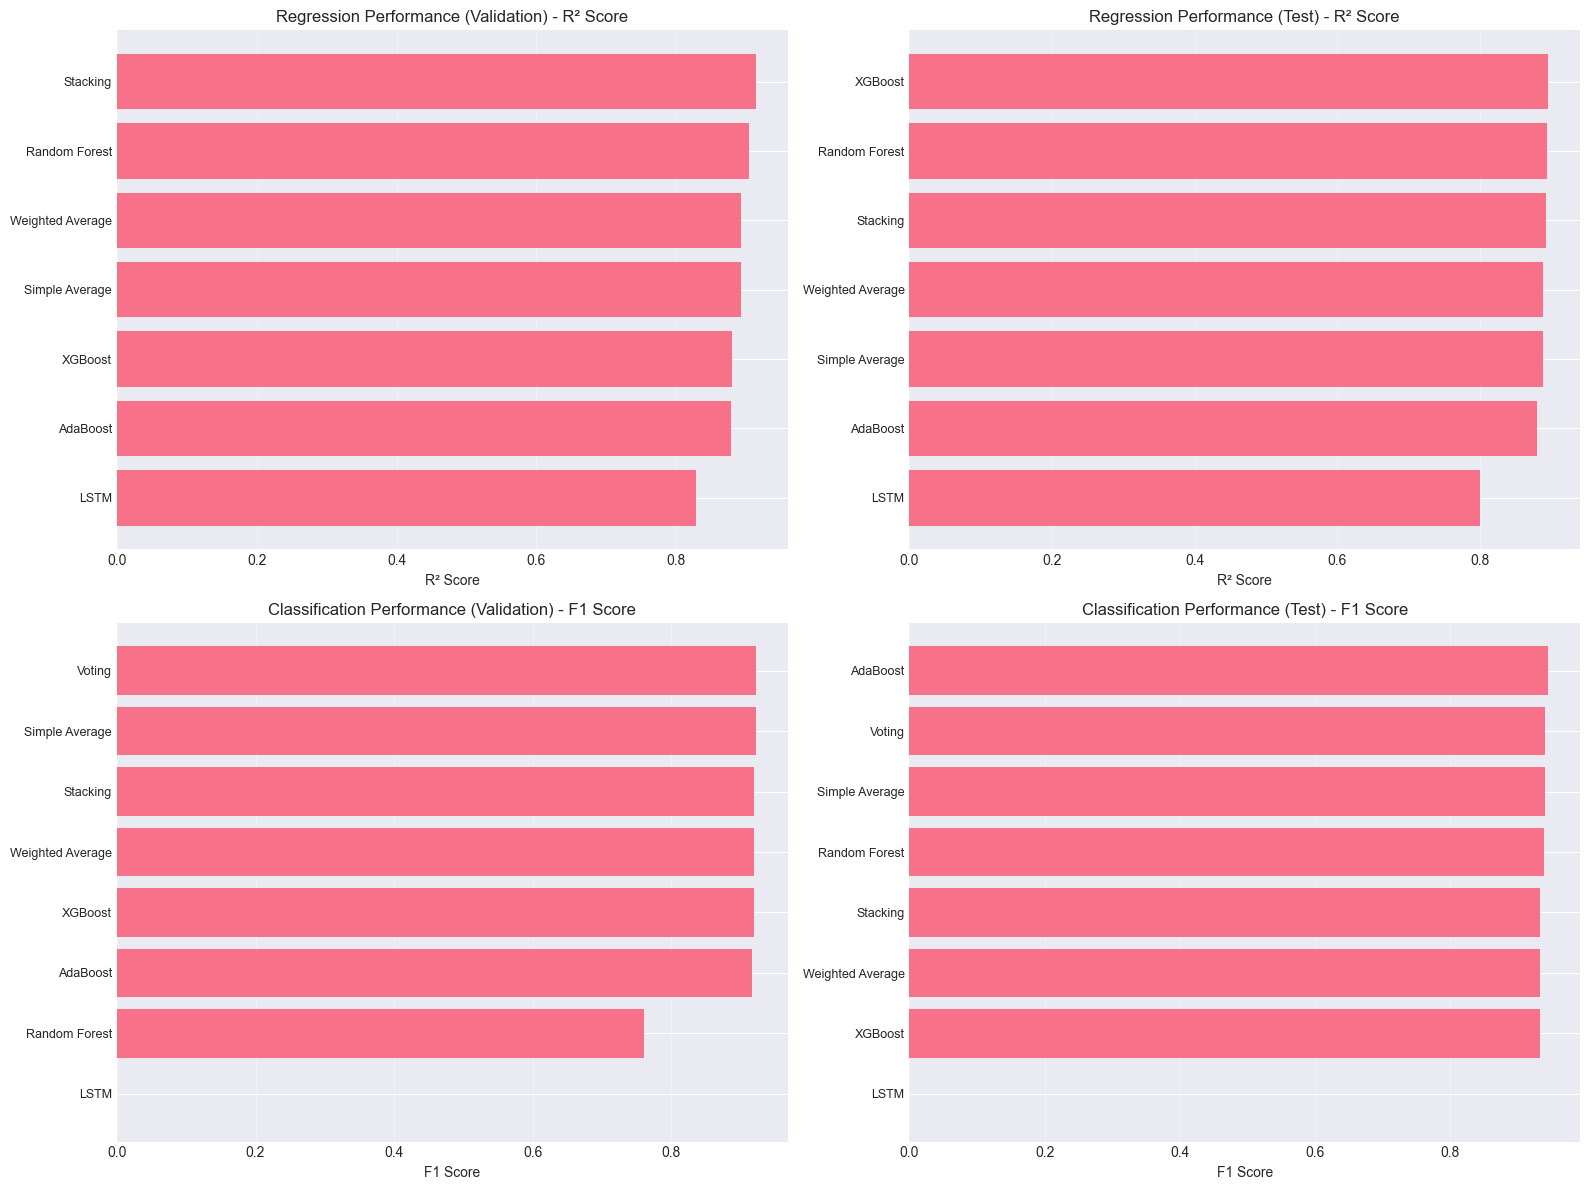

In [ ]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Regression - Validation
ax1 = axes[0, 0]
val_reg_plot = all_regression_results[all_regression_results['dataset'] == 'Validation'].copy()
val_reg_plot = val_reg_plot.sort_values('R²', ascending=True)
ax1.barh(val_reg_plot['model'], val_reg_plot['R²'])
ax1.set_xlabel('R² Score')
ax1.set_title('Regression Performance (Validation) - R² Score')
ax1.grid(axis='x', alpha=0.3)
# Adjust y-axis labels if model names are long
ax1.tick_params(axis='y', labelsize=9)

# Regression - Test
ax2 = axes[0, 1]
test_reg_plot = all_regression_results[all_regression_results['dataset'] == 'Test'].copy()
test_reg_plot = test_reg_plot.sort_values('R²', ascending=True)
ax2.barh(test_reg_plot['model'], test_reg_plot['R²'])
ax2.set_xlabel('R² Score')
ax2.set_title('Regression Performance (Test) - R² Score')
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='y', labelsize=9)

# Classification - Validation
ax3 = axes[1, 0]
val_cls_plot = all_classification_results[all_classification_results['dataset'] == 'Validation'].copy()
val_cls_plot = val_cls_plot.sort_values('F1', ascending=True)
ax3.barh(val_cls_plot['model'], val_cls_plot['F1'])
ax3.set_xlabel('F1 Score')
ax3.set_title('Classification Performance (Validation) - F1 Score')
ax3.grid(axis='x', alpha=0.3)
ax3.tick_params(axis='y', labelsize=9)

# Classification - Test
ax4 = axes[1, 1]
test_cls_plot = all_classification_results[all_classification_results['dataset'] == 'Test'].copy()
test_cls_plot = test_cls_plot.sort_values('F1', ascending=True)
ax4.barh(test_cls_plot['model'], test_cls_plot['F1'])
ax4.set_xlabel('F1 Score')
ax4.set_title('Classification Performance (Test) - F1 Score')
ax4.grid(axis='x', alpha=0.3)
ax4.tick_params(axis='y', labelsize=9)

plt.tight_layout()
# Use models/ensemble directory
ensemble_dir = os.path.join(base_path, 'models', 'ensemble') if 'base_path' in globals() else os.path.join('models', 'ensemble')
os.makedirs(ensemble_dir, exist_ok=True)
plt.savefig(os.path.join(ensemble_dir, 'ensemble_comparison.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved comparison plot: {os.path.join(ensemble_dir, 'ensemble_comparison.png')}")
plt.show()


## Step 8: Save Ensemble Predictions and Models

Save all ensemble predictions and trained meta-learners.


In [ ]:
# Create ensemble directory in models/ensemble (use base_path if defined, otherwise current directory)
ensemble_dir = os.path.join(base_path, 'models', 'ensemble') if 'base_path' in globals() else os.path.join('models', 'ensemble')
os.makedirs(ensemble_dir, exist_ok=True)
print(f"✓ Created ensemble directory: {ensemble_dir}")

# Prepare prediction DataFrames with all ensemble methods
ensemble_val_predictions = pd.DataFrame({
    'Date': val_merged['Date'].values,
    'actual_heat_index': y_val_reg,
    'actual_heat_risk': y_val_cls,
    'simple_avg_predicted_heat_index': val_reg_simple if val_reg_simple is not None else np.nan,
    'weighted_avg_predicted_heat_index': val_reg_weighted if val_reg_weighted is not None else np.nan,
    'stacking_predicted_heat_index': val_reg_stacking if val_reg_stacking is not None else np.nan,
    'simple_avg_predicted_heat_risk': val_cls_simple_binary if val_cls_simple_binary is not None else np.nan,
    'weighted_avg_predicted_heat_risk': val_cls_weighted_binary if val_cls_weighted_binary is not None else np.nan,
    'voting_predicted_heat_risk': val_cls_voting_binary if val_cls_voting_binary is not None else np.nan,
    'stacking_predicted_heat_risk': val_cls_stacking if val_cls_stacking is not None else np.nan,
    'simple_avg_predicted_heat_risk_proba': val_cls_proba_simple if val_cls_proba_simple is not None else np.nan,
    'weighted_avg_predicted_heat_risk_proba': val_cls_proba_weighted if val_cls_proba_weighted is not None else np.nan,
    'stacking_predicted_heat_risk_proba': val_cls_stacking_proba if val_cls_stacking_proba is not None else np.nan
})

ensemble_test_predictions = pd.DataFrame({
    'Date': test_merged['Date'].values,
    'actual_heat_index': y_test_reg,
    'actual_heat_risk': y_test_cls,
    'simple_avg_predicted_heat_index': test_reg_simple if test_reg_simple is not None else np.nan,
    'weighted_avg_predicted_heat_index': test_reg_weighted if test_reg_weighted is not None else np.nan,
    'stacking_predicted_heat_index': test_reg_stacking if test_reg_stacking is not None else np.nan,
    'simple_avg_predicted_heat_risk': test_cls_simple_binary if test_cls_simple_binary is not None else np.nan,
    'weighted_avg_predicted_heat_risk': test_cls_weighted_binary if test_cls_weighted_binary is not None else np.nan,
    'voting_predicted_heat_risk': test_cls_voting_binary if test_cls_voting_binary is not None else np.nan,
    'stacking_predicted_heat_risk': test_cls_stacking if test_cls_stacking is not None else np.nan,
    'simple_avg_predicted_heat_risk_proba': test_cls_proba_simple if test_cls_proba_simple is not None else np.nan,
    'weighted_avg_predicted_heat_risk_proba': test_cls_proba_weighted if test_cls_proba_weighted is not None else np.nan,
    'stacking_predicted_heat_risk_proba': test_cls_stacking_proba if test_cls_stacking_proba is not None else np.nan
})

# Save predictions
ensemble_val_predictions.to_csv(os.path.join(ensemble_dir, 'predictions_val.csv'), index=False)
ensemble_test_predictions.to_csv(os.path.join(ensemble_dir, 'predictions_test.csv'), index=False)
print("✓ Saved ensemble predictions")

# Save meta-learners (stacking models)
if stacking_regressor is not None:
    joblib.dump(stacking_regressor, os.path.join(ensemble_dir, 'stacking_regressor.pkl'))
    print("✓ Saved stacking regressor")

if stacking_classifier is not None:
    joblib.dump(stacking_classifier, os.path.join(ensemble_dir, 'stacking_classifier.pkl'))
    print("✓ Saved stacking classifier")

# Save weights
weights_dict = {
    'regression_weights': reg_weights,
    'classification_weights': cls_weights,
    'classification_proba_weights': cls_proba_weights
}
import json
with open(os.path.join(ensemble_dir, 'ensemble_weights.json'), 'w') as f:
    # Convert numpy types to native Python types for JSON serialization
    weights_json = {}
    for key, val in weights_dict.items():
        if isinstance(val, dict):
            weights_json[key] = {k: float(v) for k, v in val.items()}
        else:
            weights_json[key] = val
    json.dump(weights_json, f, indent=2)
print("✓ Saved ensemble weights")

# Save performance results
all_regression_results.to_csv(os.path.join(ensemble_dir, 'regression_results.csv'), index=False)
all_classification_results.to_csv(os.path.join(ensemble_dir, 'classification_results.csv'), index=False)
print("✓ Saved performance results")

print("\n" + "=" * 80)
print("✓ All ensemble models and predictions saved successfully!")
print("=" * 80)


✓ Created ensemble directory: ..\teams\ensemble
✓ Saved ensemble predictions
✓ Saved stacking regressor
✓ Saved stacking classifier
✓ Saved ensemble weights
✓ Saved performance results

✓ All ensemble models and predictions saved successfully!


## Summary

This notebook successfully created ensemble models combining predictions from all available models:
- Random Forest (RF): Regression and Classification
- XGBoost (XGB): Regression and Classification  
- AdaBoost (ADA): Regression and Classification
- LSTM: Regression and Classification (included when available)

### Ensemble Methods Implemented:
1. **Simple Averaging**: Equal weights for all available models
2. **Weighted Averaging**: Weights based on validation performance (R² for regression, F1 for classification)
3. **Voting**: Majority vote for classification (hard and soft voting)
4. **Stacking**: Meta-learners (Ridge for regression, LogisticRegression for classification)

### Key Features:
- **Robust Model Loading**: Handles missing or invalid prediction files gracefully
- **Ellipsis Handling**: Automatically handles "Ellipsis" placeholder values in LSTM predictions
- **Flexible Merging**: Uses actual values from any available model when others are missing
- **Complete Integration**: All available models are included in ensemble calculations

### Outputs Saved:
- `teams/ensemble/predictions_val.csv`: Validation set predictions from all ensemble methods
- `teams/ensemble/predictions_test.csv`: Test set predictions from all ensemble methods
- `teams/ensemble/stacking_regressor.pkl`: Trained stacking regressor meta-learner
- `teams/ensemble/stacking_classifier.pkl`: Trained stacking classifier meta-learner
- `teams/ensemble/ensemble_weights.json`: Weights used for weighted averaging
- `teams/ensemble/regression_results.csv`: Complete regression performance metrics (individual + ensemble)
- `teams/ensemble/classification_results.csv`: Complete classification performance metrics (individual + ensemble)
- `teams/ensemble/ensemble_comparison.png`: Visualization comparing all methods and models
